In [1]:
import re
import pandas as pd

In [2]:
with open("MeandRuby.txt", "r", encoding="utf-8") as f: # Read the file into raw lines
    lines = [line.strip() for line in f if line.strip()]

In [3]:
parsed_data = [] # Check if the line contains a timestamp separator (like " - ")
                 # This prevents wrapping everything into 1 row even if regex fails
for line in lines:
    if " - " in line:
        parsed_data.append(line)
    elif parsed_data:
        parsed_data[-1] += " " + line # Append multi-line messages to the previous row

In [4]:
df = pd.DataFrame(parsed_data, columns=["RawText"]) # Convert to DataFrame

In [5]:
df[["Date_Time", "Message_Body"]] = df["RawText"].str.split(" - ", n=1, expand=True) # Split into Date/Time block and Message block

In [6]:
df[["Date", "Time"]] = df["Date_Time"].str.split(r",\s*|\s+", n=1, expand=True, regex=True) 
# Split Date_Time into separate Date and Time columns
# Handles either ", " or " " between date and time

In [7]:
df[["Name", "Chat"]] = df["Message_Body"].str.split(": ", n=1, expand=True) # Split Message_Body into Name and Chat

In [8]:
df = df[["Date", "Time", "Name", "Chat"]] # Final column selection and clean up

In [9]:
print(f"Total rows loaded: {len(df)}")
df

Total rows loaded: 822


,Date,Time,Name,Chat
0,31/08/25,4:28 pm,Messages and calls are end-to-end encrypted. O...,None
1,08/09/25,11:27 pm,Kokila Venkatesh,You deleted this message
2,08/09/25,11:28 pm,Kokila Venkatesh,<Media omitted>
3,09/09/25,6:36 am,Rubhini Hope,The endgoal of AI is your solution
4,09/09/25,9:31 am,Rubhini Hope,<Media omitted>
...,...,...,...,...
817,16/08/26,9:00 pm,Rubhini Hope,<Media omitted>
818,16/08/26,9:02 pm,Kokila Venkatesh,Draft na epdi mam ?
819,16/08/26,9:29 pm,Rubhini Hope,Message that you've skipped the project as of ...
820,16/08/26,9:39 pm,Kokila Venkatesh,<Media omitted>


In [10]:
pd.set_option("display.max_rows", None)
df

,Date,Time,Name,Chat
0,31/08/25,4:28 pm,Messages and calls are end-to-end encrypted. O...,None
1,08/09/25,11:27 pm,Kokila Venkatesh,You deleted this message
2,08/09/25,11:28 pm,Kokila Venkatesh,<Media omitted>
3,09/09/25,6:36 am,Rubhini Hope,The endgoal of AI is your solution
4,09/09/25,9:31 am,Rubhini Hope,<Media omitted>
5,09/09/25,9:32 am,Kokila Venkatesh,So coding also has to be done mam ?
6,09/09/25,9:38 am,Rubhini Hope,<Media omitted>
7,09/09/25,9:43 am,Kokila Venkatesh,Ok mam
8,09/09/25,9:43 am,Kokila Venkatesh,Got it
9,09/09/25,9:44 am,Rubhini Hope,Okay mam


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    822 non-null    object
 1   Time    822 non-null    object
 2   Name    822 non-null    object
 3   Chat    800 non-null    object
dtypes: object(4)
memory usage: 25.8+ KB


In [12]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
#!pip install nltk

In [13]:
dataset=df

In [14]:
dataset.dropna(inplace=True)

In [16]:
import nltk
nltk.download("vader_lexicon")

[nltk_data] Downloading package vader_lexicon to C:\Users\This
[nltk_data]     PC\AppData\Roaming\nltk_data...


True

In [18]:
sid = SentimentIntensityAnalyzer()

In [19]:
senti=sid.polarity_scores(dataset['Chat'][4])

In [20]:
senti

{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [21]:
def sentimentalAnalysis(data,columnname):
        
        #downloading vader_lexicon for the process
        import matplotlib.pyplot as plt
        import seaborn as sns
        "Importing Necessary Packeage"
        from nltk.sentiment.vader import SentimentIntensityAnalyzer
        sid = SentimentIntensityAnalyzer()
        
        "Deleting null pr empty value"
        data.dropna(inplace=True)
        
        "Checking for a comment"
        #sid.polarity_scores(data[columnname][93])
        
        "Creating respective columns"
        
        data['scores'] = data[columnname].apply(lambda commentText: sid.polarity_scores(commentText))
        data['compound']  = data['scores'].apply(lambda score_dict: score_dict['compound'])
        data['Negtive']  = data['scores'].apply(lambda score_dict: score_dict['neg'])
        data['Postive']  = data['scores'].apply(lambda score_dict: score_dict['pos'])
        data['Neutral']  = data['scores'].apply(lambda score_dict: score_dict['neu'])
        
        "Creating final pos or neg using compound score"
        data['comp_score'] = data['compound'].apply(lambda c: 'pos' if c >=0 else 'neg')
        plt.clf()
        #comp=sns.countplot(x = 'comp_score', hue = 'Name', data = data, palette = 'magma')
        #comp.figure.savefig("date_charts.png")
        "Checking how many pos and neg"
        posneg=pd.DataFrame(data['comp_score'].value_counts())
        return posneg,data
    

In [22]:
pos,data_Senti=sentimentalAnalysis(dataset,columnname='Chat')

<Figure size 640x480 with 0 Axes>

In [23]:
data_Senti

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score
1,08/09/25,11:27 pm,Kokila Venkatesh,You deleted this message,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,08/09/25,11:28 pm,Kokila Venkatesh,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
3,09/09/25,6:36 am,Rubhini Hope,The endgoal of AI is your solution,"{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'comp...",0.3182,0.000,0.277,0.723,pos
4,09/09/25,9:31 am,Rubhini Hope,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
5,09/09/25,9:32 am,Kokila Venkatesh,So coding also has to be done mam ?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
6,09/09/25,9:38 am,Rubhini Hope,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
7,09/09/25,9:43 am,Kokila Venkatesh,Ok mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos
8,09/09/25,9:43 am,Kokila Venkatesh,Got it,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
9,09/09/25,9:44 am,Rubhini Hope,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.000,0.655,0.345,pos
10,15/10/25,6:47 am,Rubhini Hope,"Hi Kokila V, I hope your learning journey is g...","{'neg': 0.0, 'neu': 0.706, 'pos': 0.294, 'comp...",0.9440,0.000,0.294,0.706,pos


In [24]:
pos

,count
comp_score,
pos,766
neg,34


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [26]:
tfidf=TfidfVectorizer(max_df=0.95,min_df=2,stop_words='english')
dtm=tfidf.fit_transform(df["Chat"])

In [27]:
from sklearn.decomposition import NMF
nmf_model=NMF(n_components=5,random_state=42)
nmf_model.fit(dtm)

,n_components,5
,init,None
,solver,'cd'
,beta_loss,'frobenius'
,tol,0.0001
,max_iter,200
,random_state,42
,alpha_W,0.0
,alpha_H,'same'
,l1_ratio,0.0
,verbose,0


In [31]:
for index,topic in enumerate(nmf_model.components_):
    results=([tfidf.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print(results)

['kokila', 'days', 'progress', 'learning', 'going', 'kindly', 'check', 'update', 'media', 'omitted']
['recording', 'said', 'waiting', 'understood', 'sure', 'lemme', 'oh', 'got', 'mam', 'ok']
['just', 'shall', 'll', 'error', 'update', 'check', 'kindly', 'yes', 'got', 'mam']
['issues', 'amm', 'check', 'share', 'let', 'update', 'good', 'll', 'mam', 'okay']
['lasted', 'know', 'ultraviewer', 'end', 'like', 'hope', '00', 'understanding', 'support', 'thank']


In [32]:
topic_results=nmf_model.transform(dtm)
df["Topic"]=topic_results.argmax(axis=1)


In [33]:
df

,Date,Time,Name,Chat,scores,compound,Negtive,Postive,Neutral,comp_score,Topic
1,08/09/25,11:27 pm,Kokila Venkatesh,You deleted this message,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
2,08/09/25,11:28 pm,Kokila Venkatesh,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
3,09/09/25,6:36 am,Rubhini Hope,The endgoal of AI is your solution,"{'neg': 0.0, 'neu': 0.723, 'pos': 0.277, 'comp...",0.3182,0.000,0.277,0.723,pos,4
4,09/09/25,9:31 am,Rubhini Hope,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
5,09/09/25,9:32 am,Kokila Venkatesh,So coding also has to be done mam ?,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
6,09/09/25,9:38 am,Rubhini Hope,<Media omitted>,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
7,09/09/25,9:43 am,Kokila Venkatesh,Ok mam,"{'neg': 0.0, 'neu': 0.312, 'pos': 0.688, 'comp...",0.2960,0.000,0.688,0.312,pos,1
8,09/09/25,9:43 am,Kokila Venkatesh,Got it,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
9,09/09/25,9:44 am,Rubhini Hope,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.000,0.655,0.345,pos,3
10,15/10/25,6:47 am,Rubhini Hope,"Hi Kokila V, I hope your learning journey is g...","{'neg': 0.0, 'neu': 0.706, 'pos': 0.294, 'comp...",0.9440,0.000,0.294,0.706,pos,3


In [34]:
df["Topic"].value_counts()

Topic
0    254
2    246
3    121
1    116
4     63
Name: count, dtype: int64

In [39]:
!pip install wordCloud

In [40]:
dataset=df
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\This
[nltk_data]     PC\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [ ]:
#This ValueError: We need at least 1 word to plot a word cloud, got 0 means the string passed into wordcloud.generate(...) is empty or only contains characters that WordCloud automatically filters out as stopwords.

In [42]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [43]:
text = " ".join(df["Chat"].dropna().astype(str)) # Drop missing values and join all chat messages into one long string

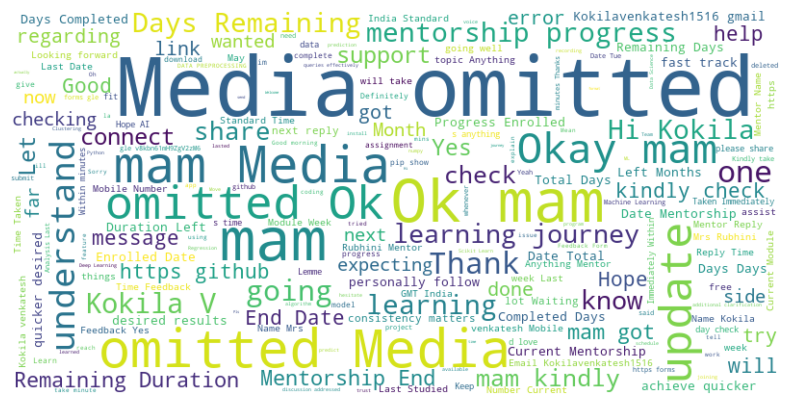

In [44]:
if len(text.strip()) > 0: # Check if text actually contains words before generating
    wordcloud = WordCloud(
        width=800, height=400, background_color="white"
    ).generate(text)

    # 3. Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()
else:
    print("No valid text found in the column to generate a WordCloud.")